# Indic Embedding Benchmark using Samanantar — Colab Version

This notebook benchmarks Indic/multilingual embedding models using the **AI4Bharat Samanantar** dataset instead of FLORES.

## Main question

> If an English sentence and its Indic translation have the same meaning, do their embeddings become close?

Samanantar is an **English-centric parallel corpus**, so this notebook evaluates:

- English → Indic retrieval
- Indic → English retrieval

It does **not** directly do Indic → Indic all-pairs evaluation by default, because Samanantar rows are aligned only within each English–Indic language subset. Unlike FLORES, the Bengali row 10 and Tamil row 10 are not guaranteed to be translations of the same English sentence.

## Dataset columns used

Samanantar examples have:

- `src`: English sentence
- `tgt`: Indic translation sentence
- `data_source`: source collection name

## Metrics

- **Accuracy@1**: correct translation is the nearest neighbour
- **Recall@10**: correct translation is in the top 10 nearest neighbours
- **MRR**: rewards the correct translation being near the top
- **Cosine gap**: true translation similarity minus random-pair similarity

## 0. Colab GPU setup

In Colab:

**Runtime → Change runtime type → Hardware accelerator → GPU → Save**

Then run the install cell below.

In [ ]:
from pathlib import Path
import sys

for _candidate in (Path.cwd(), *Path.cwd().parents):
    _guard_dir = _candidate / "scripts"
    if (_guard_dir / "import_guard.py").exists():
        if str(_guard_dir) not in sys.path:
            sys.path.insert(0, str(_guard_dir))
        break
else:
    raise RuntimeError("Could not locate scripts/import_guard.py. Run this notebook from the WSAI workspace or copy the guard module alongside it.")

from import_guard import install_pandas_guards
install_pandas_guards()


In [ ]:
# Clean packages that often break text-only Colab runs.
# We do not need torchvision/torchaudio for sentence embeddings.
!pip -q uninstall -y torchvision torchaudio torchtext fastai timm -q

# Do NOT install torch manually. Let Colab keep its working GPU torch.
!pip -q install \
  "numpy==2.0.2" \
  "scipy==1.15.3" \
  "scikit-learn==1.6.1" \
  "transformers==4.48.3" \
  "sentence-transformers==3.4.1" \
  "datasets==3.2.0" \
  "accelerate==1.3.0" \
  "pandas==2.2.2" \
  "tqdm==4.67.1" \
  "matplotlib==3.10.0" \
  "pyyaml==6.0.2" \
  "sentencepiece==0.2.0" \
  "pyarrow==17.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17

In [ ]:
import torch
import numpy as np
import scipy
import sklearn
import transformers
import sentence_transformers
import datasets
import pandas as pd

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("transformers:", transformers.__version__)
print("sentence-transformers:", sentence_transformers.__version__)
print("datasets:", datasets.__version__)
print("pandas:", pd.__version__)

torch: 2.10.0+cu128
cuda available: True
numpy: 2.0.2
scipy: 1.15.3
sklearn: 1.6.1
transformers: 4.48.3
sentence-transformers: 3.4.1
datasets: 3.2.0
pandas: 2.2.2


## 1. Mount Google Drive

This saves the sampled Samanantar pairs, embeddings, CSV metrics, error files, and plots permanently.

In [ ]:
from google.colab import drive

USE_DRIVE = True

if USE_DRIVE:
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/indic_embedding_benchmark_samanantar"
else:
    BASE_DIR = "/content/indic_embedding_benchmark_samanantar"

print("Saving outputs to:", BASE_DIR)

Mounted at /content/drive
Saving outputs to: /content/drive/MyDrive/indic_embedding_benchmark_samanantar


## 2. Imports and configuration

Start with `MAX_PAIRS_PER_LANGUAGE = 1000` or `2000`.

Samanantar is very large, so this notebook uses **streaming** and samples a manageable number of pairs per language.

In [ ]:
import gc
import os
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from datasets import load_dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
DATASET_NAME = "ai4bharat/samanantar"
SPLIT = "train"

# Number of parallel sentence pairs to evaluate per language.
# Increase this later if Colab time allows.
MAX_PAIRS_PER_LANGUAGE = 2000

# Controls memory usage during embedding.
BATCH_SIZE = 32
MAX_LENGTH = 128

# Basic text filters. These remove empty or extremely long/noisy examples.
MIN_CHARS = 3
MAX_CHARS = 500

OUTPUT_DIR = Path(BASE_DIR) / "outputs" / "samanantar_alignment_colab"
(OUTPUT_DIR / "pairs").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "embeddings").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "errors").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)

# Samanantar supports 11 English-Indic language subsets.
# Keys are short names used in our filenames and metric tables.
SAMANANTAR_LANGS = {
    "as": "Assamese",
    "bn": "Bengali",
    "gu": "Gujarati",
    "hi": "Hindi",
    "kn": "Kannada",
    "ml": "Malayalam",
    "mr": "Marathi",
    "or": "Odia",
    "pa": "Punjabi",
    "ta": "Tamil",
    "te": "Telugu",
}

# First run: keep only 2-3 models to check everything.
# Later uncomment/add more.
MODELS = [
    {"name": "labse", "hf_id": "sentence-transformers/LaBSE", "kind": "sentence_transformer"},
    {"name": "mpnet_multilingual", "hf_id": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2", "kind": "sentence_transformer"},
    {"name": "sbert_multilingual_minilm", "hf_id": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", "kind": "sentence_transformer"},

    # Backbone models: evaluated with attention-mask-aware mean pooling.
    {"name": "muril", "hf_id": "google/muril-base-cased", "kind": "hf_mean_pool"},
    {"name": "xlm_roberta_base", "hf_id": "FacebookAI/xlm-roberta-base", "kind": "hf_mean_pool"},
    {"name": "indicbertv2_ss", "hf_id": "ai4bharat/IndicBERTv2-SS", "kind": "hf_mean_pool", "trust_remote_code": True},
    {"name": "mcontriever", "hf_id": "facebook/mcontriever", "kind": "hf_mean_pool"},
]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Output dir:", OUTPUT_DIR)
print("Languages:", SAMANANTAR_LANGS)

Device: cuda
Output dir: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab
Languages: {'as': 'Assamese', 'bn': 'Bengali', 'gu': 'Gujarati', 'hi': 'Hindi', 'kn': 'Kannada', 'ml': 'Malayalam', 'mr': 'Marathi', 'or': 'Odia', 'pa': 'Punjabi', 'ta': 'Tamil', 'te': 'Telugu'}


## 3. Load Samanantar pairs

This uses Hugging Face streaming so Colab does not download the full 49M-pair dataset.

For each language subset, we collect:

- `src`: English sentence
- `tgt`: Indic translation sentence

The sampled pairs are cached to Drive as CSV files so repeated runs are faster.

In [ ]:
def clean_text(x) -> str:
    if x is None:
        return ""
    return str(x).strip()


def is_valid_pair(src: str, tgt: str) -> bool:
    src = clean_text(src)
    tgt = clean_text(tgt)
    if len(src) < MIN_CHARS or len(tgt) < MIN_CHARS:
        return False
    if len(src) > MAX_CHARS or len(tgt) > MAX_CHARS:
        return False
    return True


def load_samanantar_language_pairs(
    lang_code: str,
    max_pairs: int,
    seed: int = 42,
    use_cache: bool = True,
) -> pd.DataFrame:
    """
    Loads a sampled set of English-Indic sentence pairs from one Samanantar language subset.

    Returns a DataFrame with columns:
    - pair_id
    - lang
    - src_text: English
    - tgt_text: Indic language sentence
    - data_source
    """
    cache_path = OUTPUT_DIR / "pairs" / f"samanantar_{lang_code}_n{max_pairs}_seed{seed}.csv"

    if use_cache and cache_path.exists():
        print(f"Loading cached pairs for {lang_code}: {cache_path.name}")
        return pd.read_csv(cache_path)

    print(f"Streaming Samanantar subset: {lang_code}")

    ds = load_dataset(
        DATASET_NAME,
        lang_code,
        split=SPLIT,
        streaming=True,
    )

    # Shuffle a streaming dataset using a buffer.
    # This avoids always taking only the first source-domain examples.
    ds = ds.shuffle(seed=seed, buffer_size=10_000)

    rows = []
    for ex in tqdm(ds, desc=f"Collecting {lang_code}"):
        src = clean_text(ex.get("src", ""))
        tgt = clean_text(ex.get("tgt", ""))

        if not is_valid_pair(src, tgt):
            continue

        rows.append({
            "pair_id": len(rows),
            "lang": lang_code,
            "src_text": src,
            "tgt_text": tgt,
            "data_source": clean_text(ex.get("data_source", "")),
        })

        if len(rows) >= max_pairs:
            break

    df = pd.DataFrame(rows)

    if len(df) == 0:
        raise ValueError(f"No valid pairs collected for {lang_code}.")

    df.to_csv(cache_path, index=False)
    print(f"Saved {len(df)} pairs for {lang_code}:", cache_path)

    return df


pairs_by_lang = {}
for lang_code in SAMANANTAR_LANGS:
    pairs_by_lang[lang_code] = load_samanantar_language_pairs(
        lang_code,
        MAX_PAIRS_PER_LANGUAGE,
        SEED,
        use_cache=True,
    )

print("\nLoaded language pair counts:")
for lang_code, df in pairs_by_lang.items():
    print(lang_code, len(df))

Streaming Samanantar subset: as


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Saved 2000 pairs for as: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/pairs/samanantar_as_n2000_seed42.csv
Streaming Samanantar subset: bn


Saved 2000 pairs for bn: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/pairs/samanantar_bn_n2000_seed42.csv
Streaming Samanantar subset: gu


...

Saved 2000 pairs for mr: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/pairs/samanantar_mr_n2000_seed42.csv
Streaming Samanantar subset: or


Saved 2000 pairs for or: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/pairs/samanantar_or_n2000_seed42.csv
Streaming Samanantar subset: pa


Saved 2000 pairs for pa: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/pairs/samanantar_pa_n2000_seed42.csv
Streaming Samanantar subset: ta


Saved 2000 pairs for ta: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/pairs/samanantar_ta_n2000_seed42.csv
Streaming Samanantar subset: te


Saved 2000 pairs for te: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/pairs/samanantar_te_n2000_seed42.csv

Loaded language pair counts:
as 2000
bn 2000
gu 2000
hi 2000
kn 2000
ml 2000
mr 2000
or 2000
pa 2000
ta 2000
te 2000


In [ ]:
# Show one example from each language
for lang_code, df in pairs_by_lang.items():
    print("=" * 80)
    print(lang_code, "-", SAMANANTAR_LANGS[lang_code])
    print("EN:", df.iloc[0]["src_text"])
    print("TG:", df.iloc[0]["tgt_text"])

as - Assamese
EN: I couldnt think.
TG: ক’বলৈ গলে ভাবিব পৰা নাছিলো।
bn - Bengali
EN: He was later arrested and sent to jail.
TG: একসময় ধরা পড়ে গেলেন তিনি এবং নিক্ষিপ্ত হলেন কারাগারে।
gu - Gujarati
EN: """Last month, Bilawal had recommended the names of some 200 PPP workers and asked former Sindh Chief Minister Qaim Ali Shah to give them jobs but Talpur had intervened, causing bad blood between them,"" the source said"
TG: સૂત્રએ કહ્યું કે ગત મહિને બિલાવલે અંદાજે 200 પીપીપી કાર્યકર્તાઓના નામ સુઝવ્યા હતા અને સિંઘ પ્રાન્તના પૂર્વ મુખ્યમંત્રી કઇમ અલી શાહને તેમને કામ આપવા માટે કહ્યું હતું, પરંતુ ફારયાલે તેમા દખલગીરી કરી હતી
hi - Hindi
EN: People of Punjab want peace.
TG: पंजाब के लोग शुरू से ही अमन-शांति चाहते हैं।
kn - Kannada
EN: AAP had been insistent on an alliance in Haryana with the Congress and the rookie Jannayak Janata Party (JJP).
TG: ಇತ್ತ ಹರ್ಯಾಣದಲ್ಲೂ ಕಾಂಗ್ರೆಸ್ ಹಾಗೂ ಎಎಪಿ ಮೈತ್ರಿಯ ಜೊತೆಗೆ ಜನನಾಯಕ ಜನತಾ ಪಾರ್ಟಿ (ಜೆಜೆಪಿ) ಕೈಜೋಡಿಸಿದೆ.
ml - Malayalam
EN: No. he was on his knees surrounded by 

## 4. Embedding helpers

There are two model types:

1. **SentenceTransformer models**: already know how to produce sentence embeddings.
2. **Raw Hugging Face encoder models**: we apply attention-mask-aware mean pooling manually.

In [ ]:
@dataclass
class ModelSpec:
    name: str
    hf_id: str
    kind: str
    trust_remote_code: bool = False


def mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """
    Convert token embeddings into one sentence embedding.
    Padding tokens are ignored using attention_mask.
    """
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


class Embedder:
    def __init__(self, spec: ModelSpec, device: str, max_length: int):
        self.spec = spec
        self.device = device
        self.max_length = max_length

        if spec.kind == "sentence_transformer":
            from sentence_transformers import SentenceTransformer

            print("Loading as SentenceTransformer:", spec.hf_id)
            self.model = SentenceTransformer(
                spec.hf_id,
                device=device,
                trust_remote_code=spec.trust_remote_code,
            )
            if device == "cuda":
                self.model = self.model.half()
            self.tokenizer = None

        elif spec.kind == "hf_mean_pool":
            from transformers import AutoModel, AutoTokenizer

            print("Loading as HF mean-pool model:", spec.hf_id)
            self.tokenizer = AutoTokenizer.from_pretrained(
                spec.hf_id,
                trust_remote_code=spec.trust_remote_code,
            )
            dtype = torch.float16 if device == "cuda" else torch.float32
            self.model = AutoModel.from_pretrained(
                spec.hf_id,
                trust_remote_code=spec.trust_remote_code,
                torch_dtype=dtype,
            )
            self.model.to(device)
            self.model.eval()

        else:
            raise ValueError(f"Unknown model kind: {spec.kind}")

    @torch.no_grad()
    def encode(self, texts: List[str], batch_size: int) -> np.ndarray:
        if self.spec.kind == "sentence_transformer":
            emb = self.model.encode(
                texts,
                batch_size=batch_size,
                convert_to_numpy=True,
                normalize_embeddings=True,
                show_progress_bar=True,
            )
            return emb.astype("float32")

        all_embeddings = []

        for start in tqdm(range(0, len(texts), batch_size), desc=f"Encoding {self.spec.name}"):
            batch = texts[start:start + batch_size]

            # Correct tokenizer call. Do not add accidental arguments here.
            encoded = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt",
            )

            encoded = {k: v.to(self.device) for k, v in encoded.items()}
            outputs = self.model(**encoded)

            pooled = mean_pool(outputs.last_hidden_state, encoded["attention_mask"])
            pooled = F.normalize(pooled, p=2, dim=1)

            all_embeddings.append(pooled.detach().cpu().float().numpy())

        return np.vstack(all_embeddings).astype("float32")


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 5. Metric functions

Because each sampled Samanantar subset is aligned by row within that subset:

- English row `i` is paired with Indic row `i`

So the correct target index for source row `i` is also `i`.

In [ ]:
def compute_retrieval_metrics(
    src_emb: np.ndarray,
    tgt_emb: np.ndarray,
    top_ks: Tuple[int, ...] = (1, 5, 10)
) -> Dict[str, float]:
    # sim[i][j] = similarity between source sentence i and target sentence j
    sim = np.matmul(src_emb, tgt_emb.T)
    n = sim.shape[0]

    # For each source sentence, sort target indexes from most similar to least similar.
    sorted_idx = np.argsort(-sim, axis=1)
    ranks = np.empty(n, dtype=np.int64)

    # Since Samanantar pairs are index-aligned within each language subset,
    # correct translation for source row i is target row i.
    # ranks[i] tells where target row i appears in the nearest-neighbour list.
    for i in range(n):
        ranks[i] = int(np.where(sorted_idx[i] == i)[0][0]) + 1

    out = {
        "mrr": float(np.mean(1.0 / ranks)),
        "mean_rank": float(np.mean(ranks)),
        "median_rank": float(np.median(ranks)),
    }

    for k in top_ks:
        out[f"recall_at_{k}"] = float(np.mean(ranks <= k))

    out["accuracy_at_1"] = out["recall_at_1"]
    return out


def compute_cosine_gap(src_emb: np.ndarray, tgt_emb: np.ndarray, seed: int = 42) -> Dict[str, float]:
    rng = np.random.default_rng(seed)
    n = src_emb.shape[0]

    # Correct translation pairs: source i with target i
    pos = np.sum(src_emb * tgt_emb, axis=1)

    # Random mismatched pairs: source i with target random_j
    neg_idx = rng.permutation(n)
    for i in range(n):
        if neg_idx[i] == i:
            neg_idx[i] = (neg_idx[i] + 1) % n

    neg = np.sum(src_emb * tgt_emb[neg_idx], axis=1)

    return {
        "positive_cosine_mean": float(np.mean(pos)),
        "positive_cosine_std": float(np.std(pos)),
        "random_cosine_mean": float(np.mean(neg)),
        "random_cosine_std": float(np.std(neg)),
        "cosine_gap": float(np.mean(pos) - np.mean(neg)),
    }


def collect_errors(src_texts, tgt_texts, src_emb, tgt_emb, n_examples=25):
    sim = np.matmul(src_emb, tgt_emb.T)
    pred_idx = np.argmax(sim, axis=1)

    rows = []
    for i, p in enumerate(pred_idx):
        if p != i:
            rows.append({
                "row_id": i,
                "source_text": src_texts[i],
                "gold_translation": tgt_texts[i],
                "predicted_neighbor": tgt_texts[p],
                "gold_cosine": float(sim[i, i]),
                "predicted_cosine": float(sim[i, p]),
                "margin_pred_minus_gold": float(sim[i, p] - sim[i, i]),
            })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    return df.sort_values("margin_pred_minus_gold", ascending=False).head(n_examples)

## 6. Run Samanantar benchmark

For each model and language subset, this evaluates two directions:

1. English → Indic
2. Indic → English

Example for Hindi:

- `en-hi`
- `hi-en`

In [ ]:
DATASET_TAG = f"samanantar_{SPLIT}_n{MAX_PAIRS_PER_LANGUAGE}_seed{SEED}"
print("Dataset tag:", DATASET_TAG)

all_rows = []

for model_dict in MODELS:
    spec = ModelSpec(**model_dict)
    print(f"\n===== Model: {spec.name} | {spec.hf_id} =====")

    embedder = None

    try:
        embedder = Embedder(spec, DEVICE, MAX_LENGTH)

        for lang_code, lang_name in SAMANANTAR_LANGS.items():
            df_pairs = pairs_by_lang[lang_code]

            en_texts = df_pairs["src_text"].astype(str).tolist()
            indic_texts = df_pairs["tgt_text"].astype(str).tolist()

            en_cache_path = OUTPUT_DIR / "embeddings" / f"{spec.name}_{lang_code}_EN_{DATASET_TAG}_l{MAX_LENGTH}.npy"
            indic_cache_path = OUTPUT_DIR / "embeddings" / f"{spec.name}_{lang_code}_TGT_{DATASET_TAG}_l{MAX_LENGTH}.npy"

            # Encode/cache English side for this language subset.
            if en_cache_path.exists():
                print("Loading cached:", en_cache_path.name)
                en_emb = np.load(en_cache_path)
                if en_emb.shape[0] != len(en_texts):
                    print("English cache size mismatch. Recomputing...")
                    en_emb = embedder.encode(en_texts, batch_size=BATCH_SIZE)
                    np.save(en_cache_path, en_emb)
            else:
                en_emb = embedder.encode(en_texts, batch_size=BATCH_SIZE)
                np.save(en_cache_path, en_emb)
                print("Saved:", en_cache_path.name)

            # Encode/cache Indic side for this language subset.
            if indic_cache_path.exists():
                print("Loading cached:", indic_cache_path.name)
                indic_emb = np.load(indic_cache_path)
                if indic_emb.shape[0] != len(indic_texts):
                    print("Indic cache size mismatch. Recomputing...")
                    indic_emb = embedder.encode(indic_texts, batch_size=BATCH_SIZE)
                    np.save(indic_cache_path, indic_emb)
            else:
                indic_emb = embedder.encode(indic_texts, batch_size=BATCH_SIZE)
                np.save(indic_cache_path, indic_emb)
                print("Saved:", indic_cache_path.name)

            print(
                f"Embeddings ready | model={spec.name} | lang={lang_code} | "
                f"EN shape={en_emb.shape} | TGT shape={indic_emb.shape}"
            )

            directions = [
                ("en", lang_code, en_texts, indic_texts, en_emb, indic_emb),
                (lang_code, "en", indic_texts, en_texts, indic_emb, en_emb),
            ]

            for src_lang, tgt_lang, src_texts, tgt_texts, src_emb, tgt_emb in directions:
                pair = f"{src_lang}-{tgt_lang}"

                gap = compute_cosine_gap(src_emb, tgt_emb, SEED)
                retrieval = compute_retrieval_metrics(src_emb, tgt_emb)

                row = {
                    "model": spec.name,
                    "hf_id": spec.hf_id,
                    "dataset": DATASET_NAME,
                    "dataset_subset": lang_code,
                    "language_name": lang_name,
                    "source_language": src_lang,
                    "target_language": tgt_lang,
                    "language_pair": pair,
                    "split": SPLIT,
                    "n_examples": len(src_texts),
                    **gap,
                    **retrieval,
                }

                all_rows.append(row)

                print(
                    pair,
                    "Acc@1:", round(row["accuracy_at_1"], 4),
                    "Recall@10:", round(row["recall_at_10"], 4),
                    "MRR:", round(row["mrr"], 4),
                    "Cosine gap:", round(row["cosine_gap"], 4),
                )

                errors = collect_errors(
                    src_texts,
                    tgt_texts,
                    src_emb,
                    tgt_emb,
                    n_examples=25,
                )

                error_path = OUTPUT_DIR / "errors" / f"{spec.name}_{pair}_{DATASET_TAG}_errors.csv"
                errors.to_csv(error_path, index=False)

    except Exception as e:
        print("FAILED model:", spec.name)
        print(type(e).__name__, ":", e)
        print("Skipping this model and moving to the next one.")

    finally:
        if embedder is not None:
            del embedder
        clear_memory()


metrics_df = pd.DataFrame(all_rows)

if metrics_df.empty:
    raise ValueError(
        "No model produced results. Fix earlier model loading/encoding errors before summarizing."
    )

metrics_path = OUTPUT_DIR / f"samanantar_alignment_metrics_{DATASET_TAG}.csv"
metrics_df.to_csv(metrics_path, index=False)

print("\nSaved metrics:", metrics_path)
print("metrics_df shape:", metrics_df.shape)
display(metrics_df.head())

Dataset tag: samanantar_train_n2000_seed42

===== Model: labse | sentence-transformers/LaBSE =====
Loading as SentenceTransformer: sentence-transformers/LaBSE


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding mcontriever:   0%|          | 0/63 [00:00<?, ?it/s]

Saved: mcontriever_te_EN_samanantar_train_n2000_seed42_l128.npy


Encoding mcontriever:   0%|          | 0/63 [00:00<?, ?it/s]

Saved: mcontriever_te_TGT_samanantar_train_n2000_seed42_l128.npy
Embeddings ready | model=mcontriever | lang=te | EN shape=(2000, 768) | TGT shape=(2000, 768)
en-te Acc@1: 0.4925 Recall@10: 0.775 MRR: 0.5894 Cosine gap: 0.1487
te-en Acc@1: 0.2485 Recall@10: 0.585 MRR: 0.3623 Cosine gap: 0.148

Saved metrics: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/samanantar_alignment_metrics_samanantar_train_n2000_seed42.csv
metrics_df shape: (154, 22)


,model,hf_id,dataset,dataset_subset,language_name,source_language,target_language,language_pair,split,n_examples,...,random_cosine_mean,random_cosine_std,cosine_gap,mrr,mean_rank,median_rank,recall_at_1,recall_at_5,recall_at_10,accuracy_at_1
0,labse,sentence-transformers/LaBSE,ai4bharat/samanantar,as,Assamese,en,as,en-as,train,2000,...,0.124256,0.090728,0.521704,0.747675,117.3015,1.0,0.7275,0.7675,0.7785,0.7275
1,labse,sentence-transformers/LaBSE,ai4bharat/samanantar,as,Assamese,as,en,as-en,train,2000,...,0.123221,0.089560,0.522739,0.746619,147.5510,1.0,0.7285,0.7655,0.7755,0.7285
2,labse,sentence-transformers/LaBSE,ai4bharat/samanantar,bn,Bengali,en,bn,en-bn,train,2000,...,0.198302,0.096074,0.597741,0.962949,15.7050,1.0,0.9545,0.9730,0.9750,0.9545
3,labse,sentence-transformers/LaBSE,ai4bharat/samanantar,bn,Bengali,bn,en,bn-en,train,2000,...,0.198926,0.099196,0.597117,0.959955,18.2780,1.0,0.9520,0.9685,0.9715,0.9520
4,labse,sentence-transformers/LaBSE,ai4bharat/samanantar,gu,Gujarati,en,gu,en-gu,train,2000,...,0.213374,0.094589,0.587918,0.945193,23.6780,1.0,0.9385,0.9520,0.9560,0.9385


## 7. Summary tables

In [ ]:
# Overall model summary across all English↔Indic directions.
summary = (
    metrics_df
    .groupby("model")[["accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]]
    .mean()
    .sort_values("accuracy_at_1", ascending=False)
)

summary_path = OUTPUT_DIR / f"model_summary_{DATASET_TAG}.csv"
summary.to_csv(summary_path)

print("Saved summary:", summary_path)
display(summary)

Saved summary: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/model_summary_samanantar_train_n2000_seed42.csv


,accuracy_at_1,recall_at_10,mrr,cosine_gap
model,,,,
labse,0.930795,0.951659,0.939160,0.591812
mpnet_multilingual,0.655545,0.829523,0.717991,0.529614
muril,0.498545,0.722432,0.577353,0.003680
sbert_multilingual_minilm,0.320045,0.482000,0.377059,0.313163
mcontriever,0.210659,0.404909,0.277526,0.094932
indicbertv2_ss,0.112182,0.157955,0.130500,0.031912
xlm_roberta_base,0.099682,0.244841,0.150473,0.003984


In [ ]:
# Detailed language-pair summary.
pair_summary = (
    metrics_df
    .groupby(["model", "dataset_subset", "language_name", "source_language", "target_language", "language_pair"])[
        ["accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]
    ]
    .mean()
    .reset_index()
    .sort_values(["model", "accuracy_at_1"], ascending=[True, False])
)

pair_summary_path = OUTPUT_DIR / f"language_pair_summary_{DATASET_TAG}.csv"
pair_summary.to_csv(pair_summary_path, index=False)

print("Saved pair summary:", pair_summary_path)
display(pair_summary.head(30))

Saved pair summary: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/language_pair_summary_samanantar_train_n2000_seed42.csv


,model,dataset_subset,language_name,source_language,target_language,language_pair,accuracy_at_1,recall_at_10,mrr,cosine_gap
7,indicbertv2_ss,hi,Hindi,hi,en,hi-en,0.6850,0.8485,0.743583,0.120082
6,indicbertv2_ss,hi,Hindi,en,hi,en-hi,0.6720,0.8440,0.733679,0.119934
13,indicbertv2_ss,mr,Marathi,mr,en,mr-en,0.5265,0.7425,0.603762,0.111937
12,indicbertv2_ss,mr,Marathi,en,mr,en-mr,0.5215,0.7455,0.599981,0.112102
0,indicbertv2_ss,as,Assamese,as,en,as-en,0.0085,0.0260,0.017221,0.014534
3,indicbertv2_ss,bn,Bengali,en,bn,en-bn,0.0060,0.0210,0.013947,0.016479
9,indicbertv2_ss,kn,Kannada,kn,en,kn-en,0.0055,0.0260,0.013852,0.016706
17,indicbertv2_ss,pa,Punjabi,pa,en,pa-en,0.0045,0.0170,0.012529,0.015501
18,indicbertv2_ss,ta,Tamil,en,ta,en-ta,0.0045,0.0150,0.011675,0.013525
15,indicbertv2_ss,or,Odia,or,en,or-en,0.0040,0.0120,0.010015,0.007943


In [ ]:
# Best and worst directions per model.
best_pairs = (
    metrics_df
    .sort_values(["model", "accuracy_at_1"], ascending=[True, False])
    .groupby("model")
    .head(10)
)

worst_pairs = (
    metrics_df
    .sort_values(["model", "accuracy_at_1"], ascending=[True, True])
    .groupby("model")
    .head(10)
)

best_path = OUTPUT_DIR / f"best_pairs_{DATASET_TAG}.csv"
worst_path = OUTPUT_DIR / f"worst_pairs_{DATASET_TAG}.csv"

best_pairs.to_csv(best_path, index=False)
worst_pairs.to_csv(worst_path, index=False)

print("Saved best pairs:", best_path)
display(best_pairs[["model", "language_pair", "language_name", "accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]])

print("Saved worst pairs:", worst_path)
display(worst_pairs[["model", "language_pair", "language_name", "accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]])

Saved best pairs: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/best_pairs_samanantar_train_n2000_seed42.csv


,model,language_pair,language_name,accuracy_at_1,recall_at_10,mrr,cosine_gap
117,indicbertv2_ss,hi-en,Hindi,0.6850,0.8485,0.743583,0.120082
116,indicbertv2_ss,en-hi,Hindi,0.6720,0.8440,0.733679,0.119934
123,indicbertv2_ss,mr-en,Marathi,0.5265,0.7425,0.603762,0.111937
122,indicbertv2_ss,en-mr,Marathi,0.5215,0.7455,0.599981,0.112102
111,indicbertv2_ss,as-en,Assamese,0.0085,0.0260,0.017221,0.014534
...,...,...,...,...,...,...,...
93,xlm_roberta_base,gu-en,Gujarati,0.1195,0.2925,0.180397,0.004174
101,xlm_roberta_base,mr-en,Marathi,0.1175,0.2785,0.173934,0.004006
99,xlm_roberta_base,ml-en,Malayalam,0.1025,0.2615,0.157425,0.004391
109,xlm_roberta_base,te-en,Telugu,0.1000,0.2585,0.153145,0.004362


Saved worst pairs: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/worst_pairs_samanantar_train_n2000_seed42.csv


,model,language_pair,language_name,accuracy_at_1,recall_at_10,mrr,cosine_gap
120,indicbertv2_ss,en-ml,Malayalam,0.0020,0.0095,0.006817,0.008535
121,indicbertv2_ss,ml-en,Malayalam,0.0020,0.0120,0.007792,0.008401
124,indicbertv2_ss,en-or,Odia,0.0020,0.0100,0.007710,0.007812
126,indicbertv2_ss,en-pa,Punjabi,0.0020,0.0135,0.008179,0.014455
113,indicbertv2_ss,bn-en,Bengali,0.0025,0.0195,0.010431,0.015849
...,...,...,...,...,...,...,...
96,xlm_roberta_base,en-kn,Kannada,0.0700,0.2090,0.117563,0.004320
102,xlm_roberta_base,en-or,Odia,0.0705,0.1760,0.111674,0.003254
105,xlm_roberta_base,pa-en,Punjabi,0.0730,0.2105,0.120091,0.003924
106,xlm_roberta_base,en-ta,Tamil,0.0740,0.2145,0.123205,0.004653


## 8. Plots

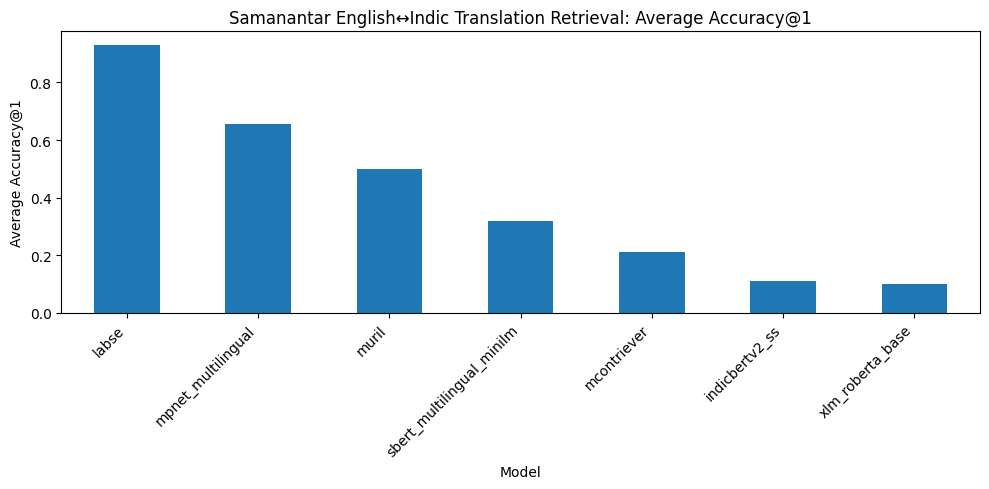

Saved plot: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/plots/average_accuracy_at_1_samanantar_train_n2000_seed42.png


In [ ]:
# Plot average Accuracy@1 by model.
model_avg_acc = (
    metrics_df
    .groupby("model")["accuracy_at_1"]
    .mean()
    .sort_values(ascending=False)
)

ax = model_avg_acc.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Average Accuracy@1")
ax.set_xlabel("Model")
ax.set_title("Samanantar English↔Indic Translation Retrieval: Average Accuracy@1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = OUTPUT_DIR / "plots" / f"average_accuracy_at_1_{DATASET_TAG}.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)

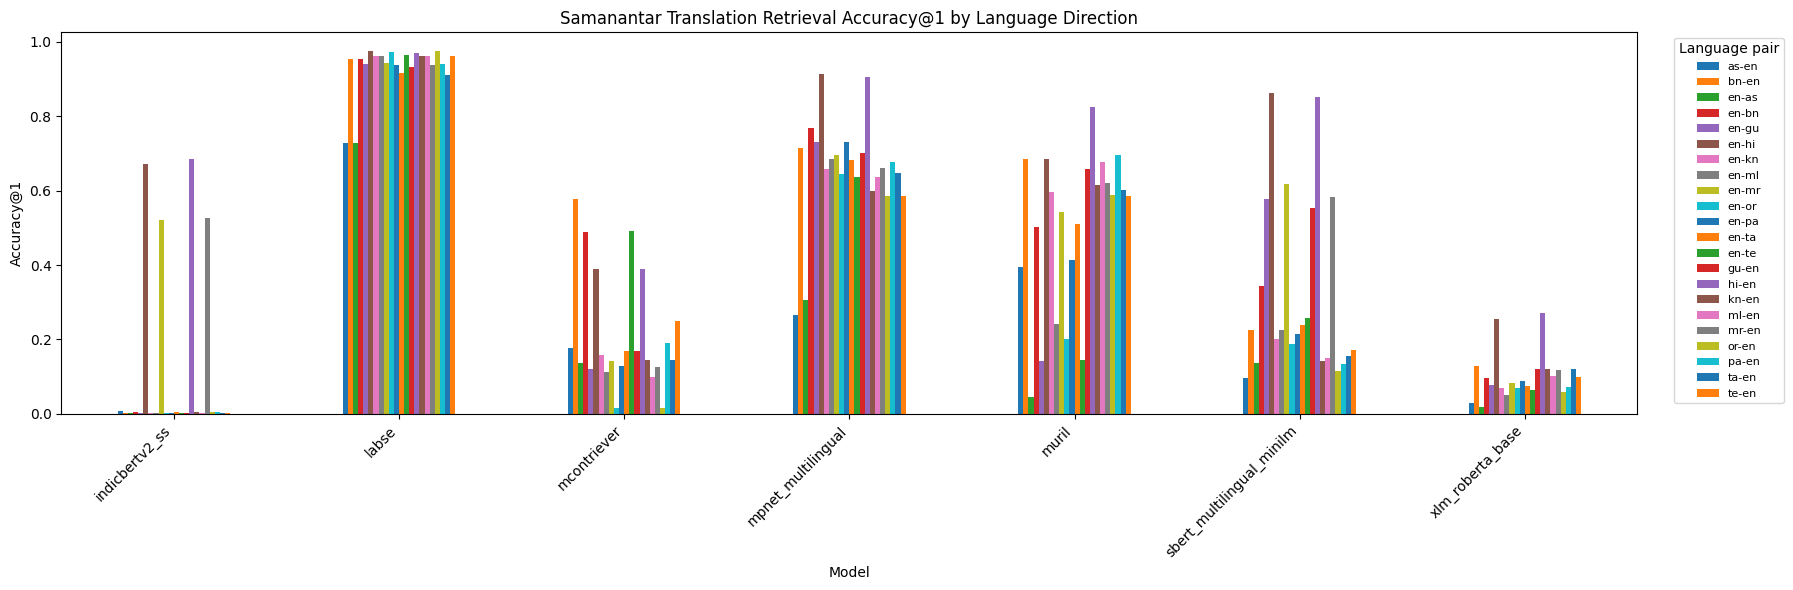

Saved plot: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/plots/accuracy_at_1_by_direction_samanantar_train_n2000_seed42.png


In [ ]:
# Plot each English→Indic and Indic→English direction separately.
pivot = metrics_df.pivot(index="model", columns="language_pair", values="accuracy_at_1")

ax = pivot.plot(kind="bar", figsize=(18, 6))
ax.set_ylabel("Accuracy@1")
ax.set_xlabel("Model")
ax.set_title("Samanantar Translation Retrieval Accuracy@1 by Language Direction")
ax.legend(title="Language pair", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = OUTPUT_DIR / "plots" / f"accuracy_at_1_by_direction_{DATASET_TAG}.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)

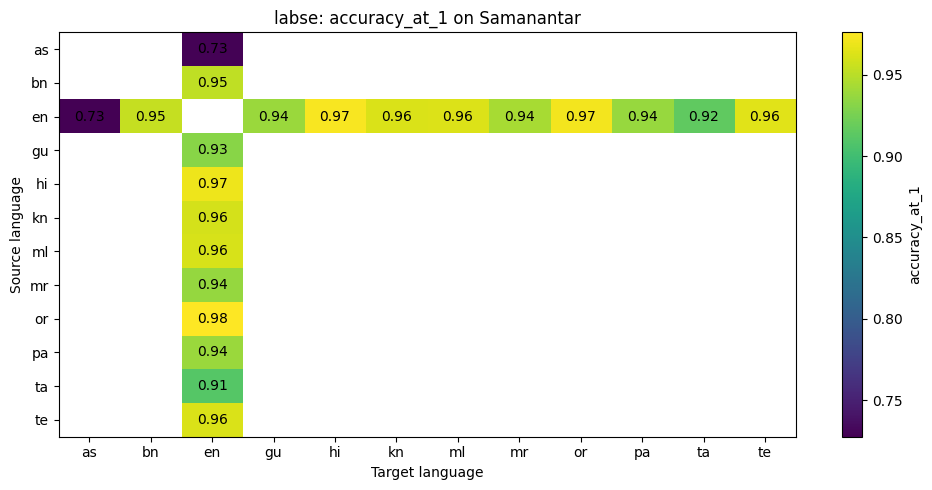

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/plots/labse_accuracy_at_1_heatmap_samanantar_train_n2000_seed42.png


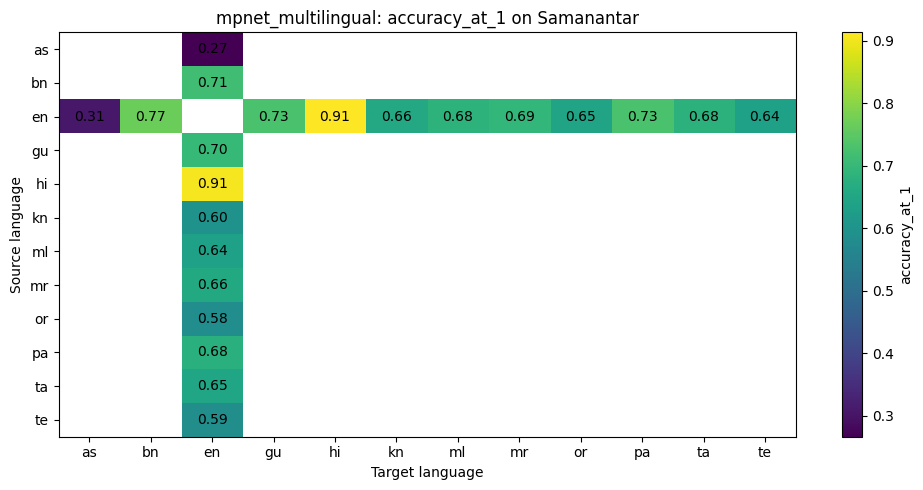

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/plots/mpnet_multilingual_accuracy_at_1_heatmap_samanantar_train_n2000_seed42.png


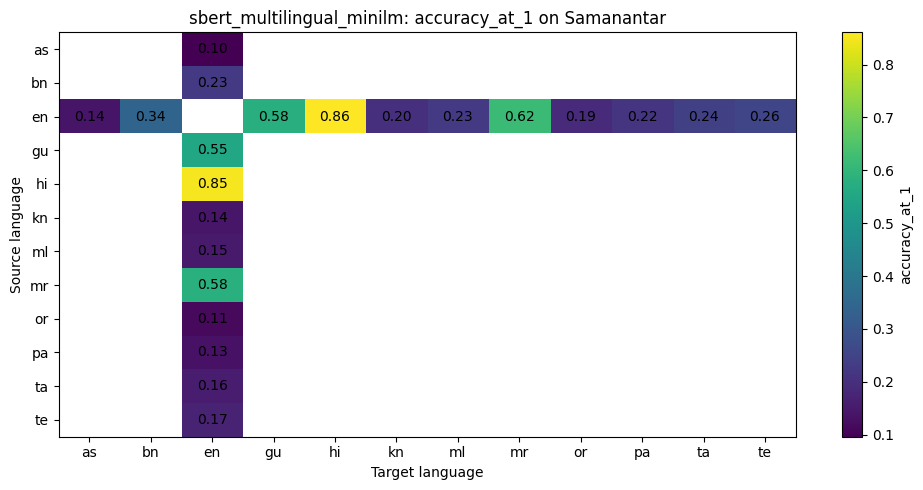

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/plots/sbert_multilingual_minilm_accuracy_at_1_heatmap_samanantar_train_n2000_seed42.png


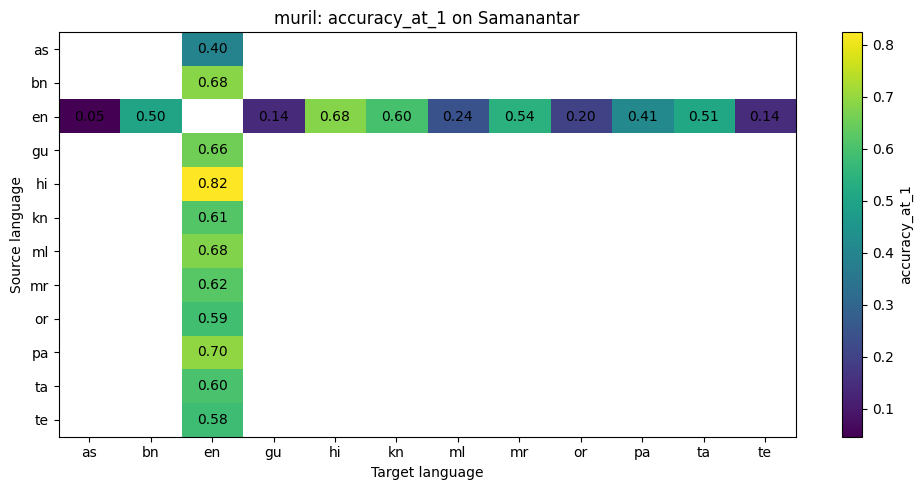

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/plots/muril_accuracy_at_1_heatmap_samanantar_train_n2000_seed42.png


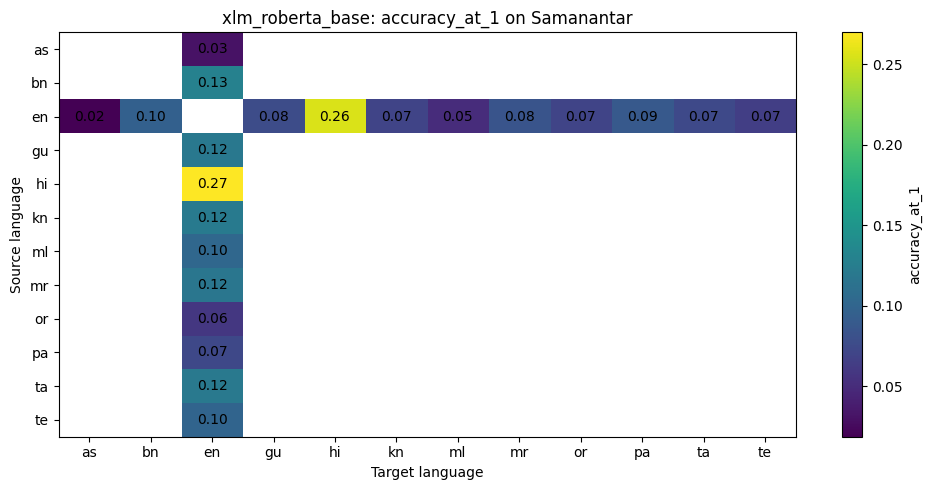

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/plots/xlm_roberta_base_accuracy_at_1_heatmap_samanantar_train_n2000_seed42.png


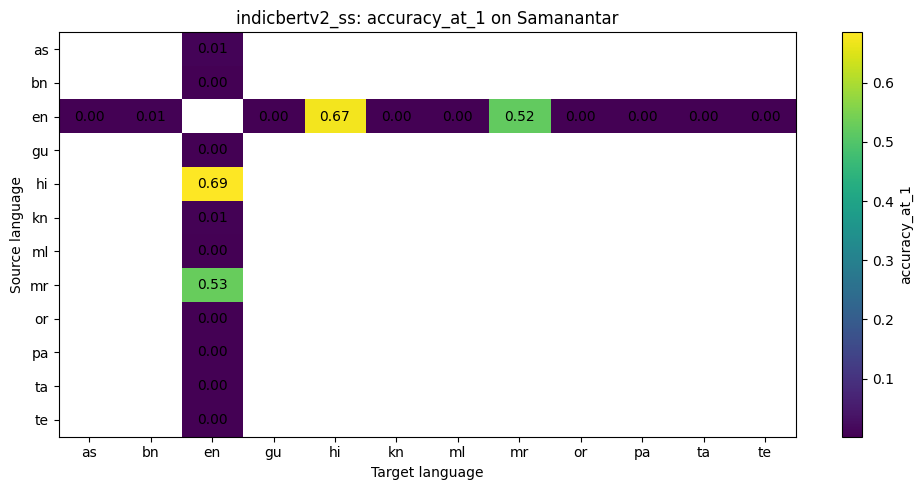

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/plots/indicbertv2_ss_accuracy_at_1_heatmap_samanantar_train_n2000_seed42.png


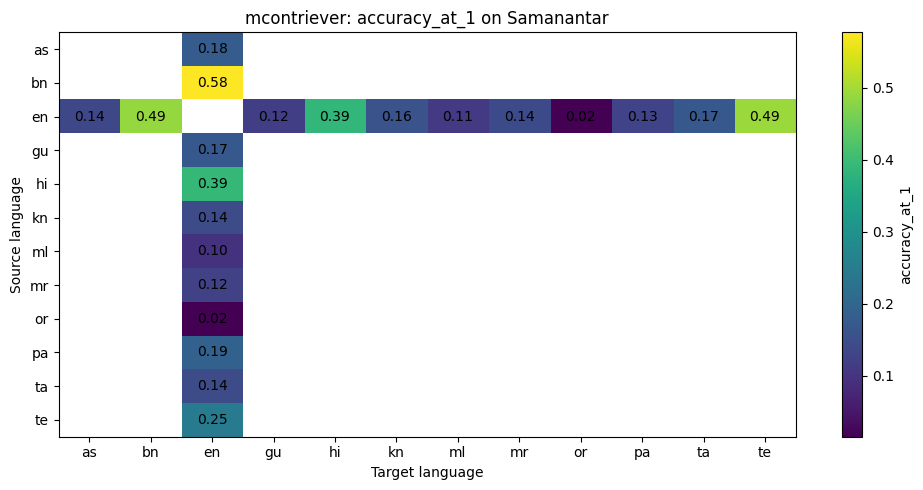

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/plots/mcontriever_accuracy_at_1_heatmap_samanantar_train_n2000_seed42.png


In [ ]:
# Heatmap helper: one model at a time.
def plot_model_heatmap(metrics_df, model_name, metric="accuracy_at_1"):
    model_df = metrics_df[metrics_df["model"] == model_name]

    heatmap_data = model_df.pivot(
        index="source_language",
        columns="target_language",
        values=metric,
    )

    plt.figure(figsize=(10, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label=metric)

    plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
    plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
    plt.title(f"{model_name}: {metric} on Samanantar")
    plt.xlabel("Target language")
    plt.ylabel("Source language")

    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not pd.isna(value):
                plt.text(j, i, f"{value:.2f}", ha="center", va="center")

    plt.tight_layout()
    plot_path = OUTPUT_DIR / "plots" / f"{model_name}_{metric}_heatmap_{DATASET_TAG}.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()
    print("Saved heatmap:", plot_path)


for model_name in metrics_df["model"].unique():
    plot_model_heatmap(metrics_df, model_name, metric="accuracy_at_1")

## 9. Inspect error examples

The error files show cases where the model's nearest neighbour was not the correct translation.

In [ ]:
import glob

error_files = sorted(glob.glob(str(OUTPUT_DIR / "errors" / f"*_{DATASET_TAG}_errors.csv")))

print("Number of error files:", len(error_files))
print("\nFirst 10 error files:")
for path in error_files[:10]:
    print(path)

ERROR_FILE_INDEX = 0

if error_files:
    sample_error_path = error_files[ERROR_FILE_INDEX]
    print("\nShowing errors from:", sample_error_path)
    sample_errors = pd.read_csv(sample_error_path)
    display(sample_errors.head(10))
else:
    print("No error files found.")

Number of error files: 154

First 10 error files:
/content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/errors/indicbertv2_ss_as-en_samanantar_train_n2000_seed42_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/errors/indicbertv2_ss_bn-en_samanantar_train_n2000_seed42_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/errors/indicbertv2_ss_en-as_samanantar_train_n2000_seed42_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/errors/indicbertv2_ss_en-bn_samanantar_train_n2000_seed42_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/errors/indicbertv2_ss_en-gu_samanantar_train_n2000_seed42_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark_samanantar/outputs/samanantar_alignment_colab/errors/indicbertv2_ss_en-hi_samanan

,row_id,source_text,gold_translation,predicted_neighbor,gold_cosine,predicted_cosine,margin_pred_minus_gold
0,763,পুৱাই জম্মু-কাশ্মীৰত সন্ত্ৰাসবাদীৰে সংঘৰ্ষত আহ...,One terrorist gunned down by security personne...,She offers more than what might normally be ex...,0.457270,0.720860,0.263590
1,407,যোৱা শুই থাকা।,Lie down,Please bring me my purse.,0.391740,0.619024,0.227284
2,1016,বিজেপিৰ ৰাষ্ট্ৰীয় সভাপতি অমিত শ্বাহে আজি উত্তৰ...,BJP National President Amit Shah To Visit Nort...,"Whether, when an audio CD is inserted, gnome-v...",0.460704,0.680774,0.220070
3,172,কথাত মচগুল চীনা ৰাষ্ট্ৰপতি জিনপিং আৰু ভাৰতৰ প্...,Chinese President Xi Jinping and PM Narendra Modi,She offers more than what might normally be ex...,0.478752,0.683113,0.204362
4,1511,ভাৰতৰ যোগাযোগ মন্ত্ৰালয় আৰু জাপানৰ অন্তঃৱৰ্তী ...,MOC in Postal Field between the Ministry of Co...,"IN SOME countries, children love to tease a pl...",0.487993,0.689625,0.201632
5,1489,পঞ্চভূতত বিলীন প্ৰাক্তন বিদেশ মন্ত্ৰী সুষমা স্...,"Minister of External Affairs, Sushma Swaraj",Language object to get highlighting patterns from,0.476278,0.676956,0.200678
6,973,এটা সুকীয়া কোঠাত ৰখা হোৱা মাতৃ আৰু সন্তান দুয়ো...,The baby and the mother were safe and healthy.,( a) The questions at Job 38: 19 might bring u...,0.520492,0.716552,0.196060
7,1364,যু. পূ.,Their 40 - year wilderness sojourn is about to...,This is Assam.,0.487108,0.678096,0.190988
8,1008,প্ৰধানমন্ত্ৰী নৰেন্দ্ৰ মোদীক আজি ৭০সংখ্যক জন্ম...,Wishing PM Narendra Modi ji a happy birthday,"Whether, when an audio CD is inserted, gnome-v...",0.525999,0.715802,0.189803
9,1121,হাইস্কুল আৰু হাইমাদ্ৰাছা পৃথকীকৰণ.,High School and Junior College.,WARNING - Caribou: unhandled editable widget:,0.500899,0.690607,0.189709


## 10. Notes for interpretation

Use these points in your documentation:

- Samanantar is much larger than FLORES, but it is noisier because it includes mined and collected web-scale parallel data.
- This notebook uses a sampled evaluation set for speed and reproducibility.
- Samanantar is English-centric, so the primary valid benchmark is English↔Indic translation retrieval.
- Models trained specifically for sentence embeddings usually perform better than raw encoder backbones with simple mean pooling.
- Backbone results should be treated as exploratory unless the model is fine-tuned for sentence similarity/alignment.